### Imports

In [2]:
import os
import neptune as neptune
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

# functions

In [3]:
def get_neptune_table(tags, negative_tags=None, columns=None):
    """
    Fetches a Neptune runs table filtered by tags and returns it as a pandas DataFrame.

    Parameters:
    - tags (list): List of tags to filter the runs.
    - negative_tags (list, optional): List of tags to exclude from the runs.
    - columns (list, optional): Additional columns to include in the runs table.

    Returns:
    - pandas.DataFrame: The runs table with the specified filters and columns.
    """

    # Initialize the Neptune project
    project = neptune.init_project(
        project="pmtest/llm-random",
        mode="read-only",
        api_token=os.environ["NEPTUNE_API_TOKEN"],
    )

    # Fetch the runs table with the specified tags and columns
    runs_table = project.fetch_runs_table(tag=tags, columns=columns).to_pandas()

    # Ensure 'sys/tags' is a list for each run
    # print(f"runs_table: {runs_table}")
    runs_table["sys/tags"] = runs_table["sys/tags"].apply(
        lambda x: x.split(",") if isinstance(x, str) else x
    )

    # Exclude runs containing any of the negative tags
    if negative_tags:
        for neg_tag in negative_tags:
            runs_table = runs_table[
                ~runs_table["sys/tags"].apply(lambda x: neg_tag in x)
            ]

    print(f"Table downloaded\nShape: {runs_table.shape}")
    return runs_table

def get_loss_per_step(runs_table, field_name='steps/train/loss'):
    loss_dict = {}
    not_finished_exps = 0
    for _, run_row in runs_table.iterrows():
        run_id = run_row['sys/id']  # Assuming 'sys/id' is the run identifier
        print(f'run ID: {run_id}')
        project_name = "pmtest/llm-random"
        # run_id = "LLMRANDOM-2078"
        run = neptune.init_run(
            project=project_name,
            with_id=run_id,
            mode="read-only",
            api_token=os.environ["NEPTUNE_API_TOKEN"],
        )
        last_step = run_row['step']
        n_steps = run_row['job_config/trainer_factory/n_steps']
        if int(last_step + 1) == n_steps:
            loss_dict[run_id] = run[field_name].fetch_values()
        else:
            print(f'{run_id}: {int(last_step + 1)}/{n_steps} steps')
            not_finished_exps += 1
    if not_finished_exps > 0:
        print(f"WARNING only {runs_table.shape[0] - not_finished_exps}/{runs_table.shape[0]} completed")
    return loss_dict

def df_per_step(df, per_step):
    # Calculate the rolling average of 'value' column with window size `per_step`
    df['value'] = df['value'].rolling(window=per_step, min_periods=1).mean()

    # Select every `per_step`-th row from the end backwards, excluding the first step
    selected_indices = list(range(len(df) - 1, 0, -per_step))  # Start from second last to skip the first step
    selected_rows = df.iloc[selected_indices]

    # Sort the selected rows to maintain ascending step order
    selected_rows = selected_rows.sort_index()

    return selected_rows

def calculate_speedup(a, b, equation):
    if equation == '(b-a)/b':
        speedup = (b - a) / b
    elif equation == '(b-a)/a':
        speedup = (b - a) / a
    elif equation == 'b/a':
        speedup = b / a
    else:
        return None

    return speedup

def plot_std(runs_1, runs_2, title, name_1, name_2, negative_tags=['remove'], show_plot=False, save_to=None, figsize=(10, 10), ylim=None, x_start=None, loss_per=None, tokens_in='B.5', loss_field_name='steps/train/loss'):
    table_1 = get_neptune_table(runs_1, negative_tags)
    table_2 = get_neptune_table(runs_2, negative_tags)

    loss_dict_1 = get_loss_per_step(table_1, field_name=loss_field_name)
    loss_dict_2 = get_loss_per_step(table_2, field_name=loss_field_name)

    seq_len = table_1['job_config/model/common/sequence_length'].iloc[0]
    batch_size = table_1['job_config/training/dataloader/total_batch_size'].iloc[0]
    tokens_per_step = batch_size * seq_len

    only_2_runs = False
    if table_1.shape[0] + table_2.shape[0] == 2:
        only_2_runs = True

    # Concatenate the dataframes into one
    df_1 = pd.concat([df.set_index('step')['value'] for df in loss_dict_1.values()], axis=1)
    if loss_per == None:
        loss_per = int(df_1.shape[0] / 100)
    df_1 = df_per_step(df_1, loss_per)
    df_2 = pd.concat([df.set_index('step')['value'] for df in loss_dict_2.values()], axis=1)
    df_2 = df_per_step(df_2, loss_per)

    # Calculate mean and standard deviation
    df_1['mean'] = df_1.mean(axis=1)
    df_1['std'] = df_1.std(axis=1)

    # Calculate mean and standard deviation
    df_2['mean'] = df_2.mean(axis=1)
    df_2['std'] = df_2.std(axis=1)

    df_1['tokens'] = df_1.index * tokens_per_step
    df_2['tokens'] = df_2.index * tokens_per_step

    # Reset the index to have 'step' as a column again
    df_1 = df_1[['tokens', 'mean', 'std']].reset_index()
    df_2 = df_2[['tokens', 'mean', 'std']].reset_index()

    if show_plot:
        # Create the plot
        plt.figure(figsize=figsize)

        # baseline
        steps = df_1['tokens'].values
        mean_values = df_1['mean'].values
        std_values = df_1['std'].values

        if x_start is not None:
            first_index = np.argmax(steps > x_start)
            steps = steps[first_index:]
            mean_values = mean_values[first_index:]
            std_values = std_values[first_index:]

        if only_2_runs:
            plt.plot(steps, mean_values, label=f'{name_1}', color='blue')
        else:
            plt.plot(steps, mean_values, label=f'{name_1} - mean', color='blue')
            plt.fill_between(steps, mean_values - std_values, mean_values + std_values,
                            color='blue', alpha=0.2, label=f'{name_1} - std')

        #relative
        steps = df_2['tokens'].values
        mean_values = df_2['mean'].values
        std_values = df_2['std'].values

        if x_start is not None:
            steps = steps[first_index:]
            mean_values = mean_values[first_index:]
            std_values = std_values[first_index:]

        if only_2_runs:
            plt.plot(steps, mean_values, label=f'{name_2}', color='red')
        else:
            plt.plot(steps, mean_values, label=f'{name_2} - mean', color='red')
            plt.fill_between(steps, mean_values - std_values, mean_values + std_values,
                            color='red', alpha=0.2, label=f'{name_2} - std')

        # # Plot individual dataframes from the dictionary
        # for run_id, df in relative_loss_dict.items():
        #     plt.plot(df['step'].values, df['value'].values, label=f'Run {run_id}')

        # Add labels and title
        if tokens_in == 'B':
            plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-9:.0f}B'))
        elif tokens_in == 'B.5':
            plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-9:.1f}B'))
        elif tokens_in == 'M':
            plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-6:.0f}M'))

        plt.xlabel('Tokens', fontsize=24)
        plt.ylabel('Loss', fontsize=24)
        plt.xticks(rotation=45, fontsize=20)
        plt.yticks(fontsize=20)

        if ylim is not None:
            plt.ylim(ylim)
        plt.title(title, fontsize=26)  # Set title font size x2
        # Show legend
        plt.legend(fontsize=20)
        plt.tight_layout()
        if save_to is not None:
            plt.savefig(save_to)
        # Show the plot
        plt.show()

    # For baseline_df: Find the step with the lowest loss
    min_loss_index_baseline = df_1['mean'].idxmin()
    loss_baseline = df_1['mean'].values[min_loss_index_baseline]
    std_baseline = df_1['std'].values[min_loss_index_baseline]
    min_step_baseline = df_1['step'].values[min_loss_index_baseline]

    # For relative_df: Find the first step where the mean loss is smaller than the baseline's minimum loss
    smaller_loss_condition = df_2['mean'] <= loss_baseline

    if smaller_loss_condition.any():  # Check if there's any step with a smaller mean loss
        first_smaller_step_relative = df_2[smaller_loss_condition]['step'].values[0]
        loss_relative = df_2[smaller_loss_condition]['mean'].values[0]
        std_relative = df_2[smaller_loss_condition]['std'].values[0]

        # Calculate speedup using the found steps
        speedup = calculate_speedup(a=first_smaller_step_relative, b=min_step_baseline, equation='b/a')
    else:
        # No step has a smaller mean loss
        first_smaller_step_relative = None
        loss_relative = None
        std_relative = None
        speedup = None

    return (min_step_baseline, loss_baseline, std_baseline), (first_smaller_step_relative, loss_relative, std_relative), speedup

# Main

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (5, 345)
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (5, 345)
run ID: LLMRANDOM-35613
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35613
run ID: LLMRANDOM-35612
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35612
run ID: LLMRANDOM-35610
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35610
run ID: LLMRANDOM-35601
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35601
run ID: LLMRANDOM-35600
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35600
run ID: LLMRANDOM-35617
[nept

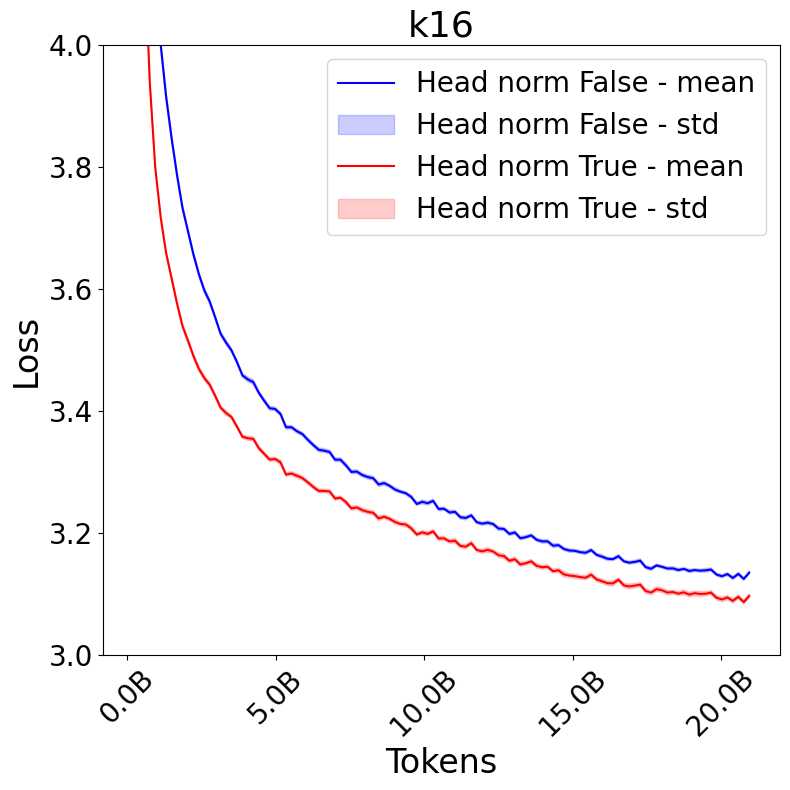

speedup: 1.3134328358208955


In [4]:
b_v_r_tags_baseline = ['head_norm', 'k16', 'hnorm=False']
b_v_r_tags_relative = ['head_norm', 'k16', 'hnorm=True']

(all_steps, baseline_loss, baseline_std), (relative_steps, relative_loss, relative_std), speedup = plot_std(
    runs_1=b_v_r_tags_baseline,
    runs_2=b_v_r_tags_relative,
    title='k16',
    name_1='Head norm False',
    name_2='Head norm True',
    show_plot=True,
    save_to='token_reduction/jm/k16_hnorm.pdf',
    ylim=(3.0, 4.0),
    x_start=0,
    loss_per=None,
    figsize=(8, 8),
    tokens_in='B.5',
    loss_field_name='steps/eval/loss',
)

print(f'speedup: {speedup}')
# tokens_per_step = 128 * 512
# print(f'total tokens: {round(all_steps * tokens_per_step / 1000000, 0)}M, relative tokens: {round(relative_steps * tokens_per_step / 1000000, 0)}M')
# print(f'std baseline: {baseline_std}, std relative: {relative_std}')

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (3, 259)
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (3, 259)
run ID: LLMRANDOM-35616
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35616
run ID: LLMRANDOM-35615
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35615
run ID: LLMRANDOM-35614
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35614
run ID: LLMRANDOM-35611
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35611
run ID: LLMRANDOM-35609
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-35609
run ID: LLMRANDOM-35608
[nept

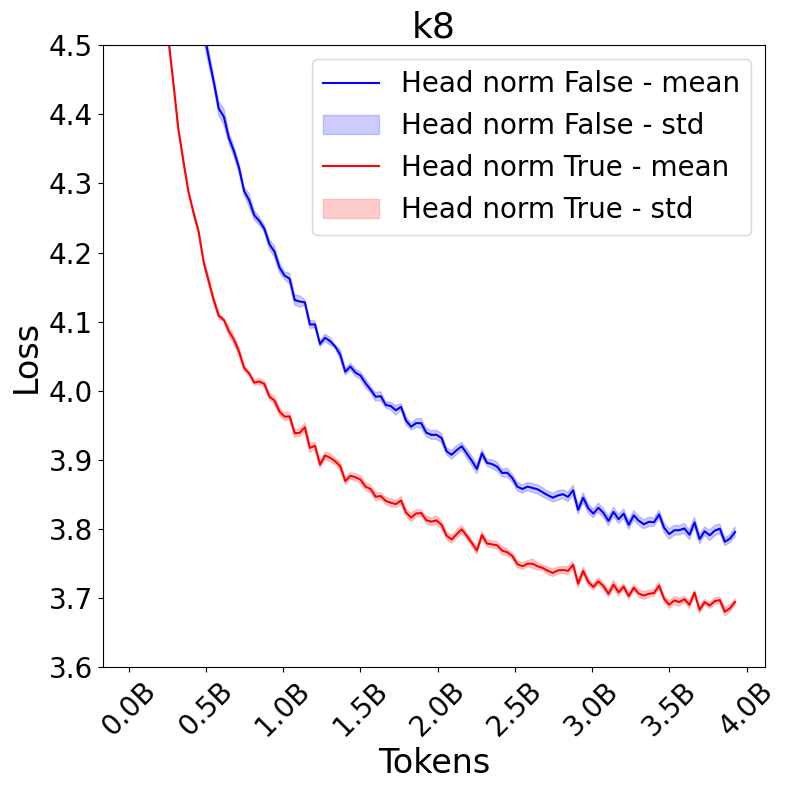

speedup: 1.7374631268436578


In [5]:
b_v_r_tags_baseline = ['head_norm', 'k8', 'hnorm=False']
b_v_r_tags_relative = ['head_norm', 'k8', 'hnorm=True']

(all_steps, baseline_loss, baseline_std), (relative_steps, relative_loss, relative_std), speedup = plot_std(
    runs_1=b_v_r_tags_baseline,
    runs_2=b_v_r_tags_relative,
    title='k8',
    name_1='Head norm False',
    name_2='Head norm True',
    show_plot=True,
    save_to='token_reduction/jm/k16_hnorm.pdf',
    ylim=(3.6, 4.5),
    x_start=0,
    loss_per=None, 
    figsize=(8, 8),
    tokens_in='B.5',
    loss_field_name='steps/eval/loss',
)

print(f'speedup: {speedup}')
# tokens_per_step = 128 * 512
# print(f'total tokens: {round(all_steps * tokens_per_step / 1000000, 0)}M, relative tokens: {round(relative_steps * tokens_per_step / 1000000, 0)}M')
# print(f'std baseline: {baseline_std}, std relative: {relative_std}')

In [6]:
b_v_r_tags_baseline = ['head_norm', 'k24', 'hnorm=False']
b_v_r_tags_relative = ['head_norm', 'k24', 'hnorm=True']

(all_steps, baseline_loss, baseline_std), (relative_steps, relative_loss, relative_std), speedup = plot_std(
    runs_1=b_v_r_tags_baseline,
    runs_2=b_v_r_tags_relative,
    title='k16',
    name_1='Head norm False',
    name_2='Head norm True',
    show_plot=True,
    save_to='token_reduction/jm/k16_hnorm.pdf',
    ylim=(3.6, 4.5),
    x_start=0,
    loss_per=None, 
    figsize=(8, 8),
    tokens_in='B.5',
    loss_field_name='steps/eval/loss',
)

print(f'speedup: {speedup}')
# tokens_per_step = 128 * 512
# print(f'total tokens: {round(all_steps * tokens_per_step / 1000000, 0)}M, relative tokens: {round(relative_steps * tokens_per_step / 1000000, 0)}M')
# print(f'std baseline: {baseline_std}, std relative: {relative_std}')

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/llm-random/


KeyError: 'sys/tags'